# Bagian 1 : Model Prediksi Kepadatan Lalu lintas
Tujuan: Memprediksi kepadatan jumlah kendaraan di berbagai area di kota yang diintepretasikan sebagai "zona". Dikarenkan kesalahan besar dalam memprediksi macet sangat fatal bagi "pihak yang bertanggung jawab" untuk dapat mengatur 'rencana' untuk menyelesaikan 'kepadatan/ kemacetan' tersebut maka dari itu kita menggunakan metrik **RMSE** sebagai indikator utama performa model

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score,confusion_matrix
from sklearn.model_selection import cross_val_score

In [9]:
df_traffic = pd.read_csv('traffic_history.csv')
display(df_traffic.head())
display(df_traffic.info())

,timestamp,hour,day_of_week,weather_code,prev_density,location,vehicle_density
0,2024-01-01T00:00:00,0,0,1,4.239262,zone1,1.848862
1,2024-01-01T00:00:00,0,0,0,6.514264,zone2,0.000000
2,2024-01-01T00:00:00,0,0,3,0.000000,zone3,0.000000
3,2024-01-01T00:00:00,0,0,3,19.411606,zone4,13.413698
4,2024-01-01T00:30:00,0,0,0,18.904774,zone1,21.058567


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        20000 non-null  object 
 1   hour             20000 non-null  int64  
 2   day_of_week      20000 non-null  int64  
 3   weather_code     20000 non-null  int64  
 4   prev_density     20000 non-null  float64
 5   location         20000 non-null  object 
 6   vehicle_density  20000 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.1+ MB


None

### 1.1 Melakukan pemeriksaan 'penyakit data' seperti :
1. Redudansi: Membuang baris duplikat (trimming)
2. Missing Values: Menggunakan interpolasi linear (Time-Series)

In [10]:
# Duplikat
df_traffic = df_traffic.drop_duplicates(subset=['timestamp', 'location'])

# Eksekusi Interpolasi pada data yang 'terputus'
df_traffic['vehicle_density'] = df_traffic['vehicle_density'].interpolate(method='linear')


###1.2 EDA analysis

#### 1.2.1 Visualisasi Jam Kepaadaatan (Traffic)

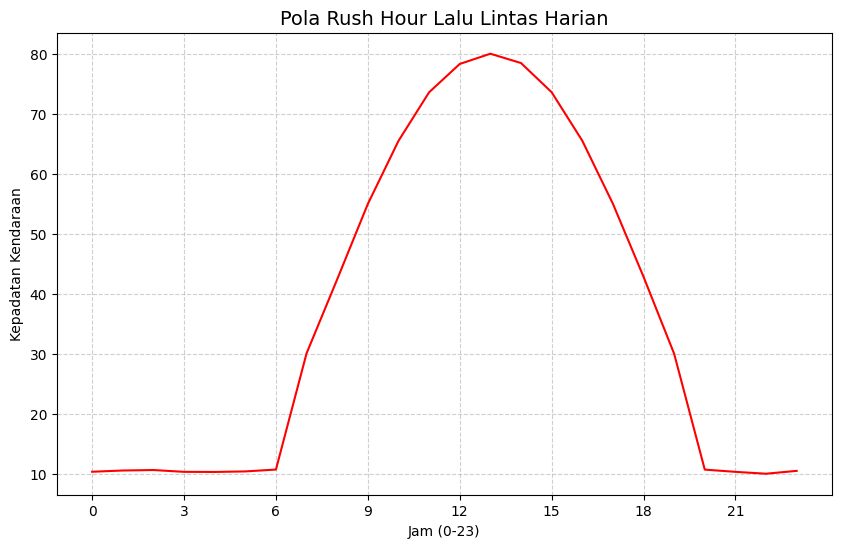

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_traffic, x='hour', y='vehicle_density', errorbar=None, color='red')
plt.title("Pola Rush Hour Lalu Lintas Harian", fontsize=14)
plt.xticks(np.arange(0, 24, 3))
plt.xlabel("Jam (0-23)")
plt.ylabel("Kepadatan Kendaraan")
plt.grid(True, linestyle='--', alpha=0.6)

#### 1.2.2 Visualisasi kepatan kendaraan

Text(0, 0.5, 'Frekuensi')

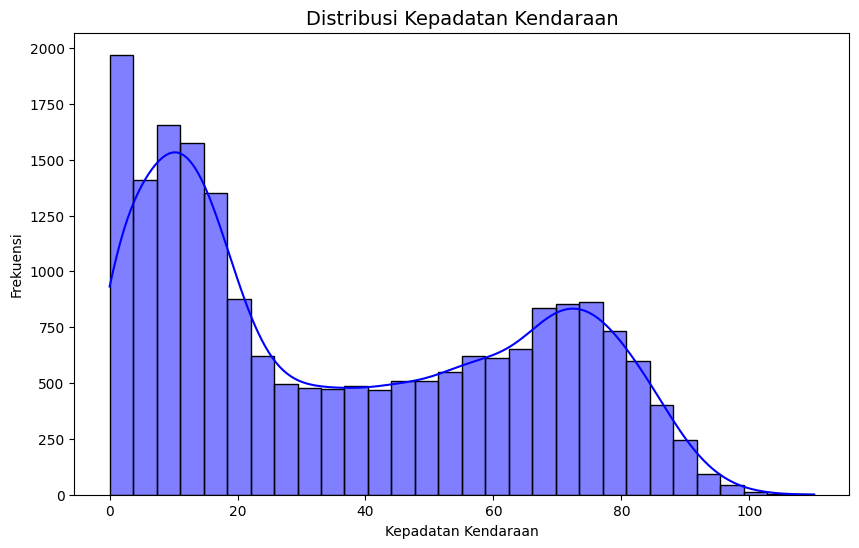

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df_traffic['vehicle_density'], kde=True, color='blue', bins=30)
plt.title("Distribusi Kepadatan Kendaraan", fontsize=14)
plt.xlabel("Kepadatan Kendaraan")
plt.ylabel("Frekuensi")

####1.2.3 Visualisasi Correlation Matrix pada fitur numerikal


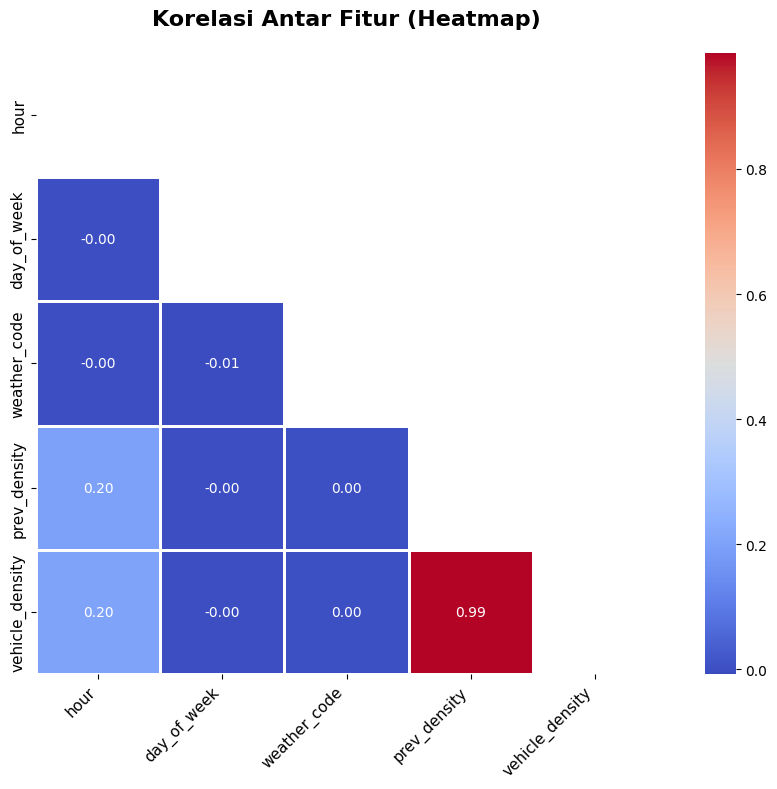

In [13]:
numeric_cols = df_traffic.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_cols.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.8,
    annot_kws={"size": 10},
    square=True
)

plt.title("Korelasi Antar Fitur (Heatmap)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

### 1.3 Analisis Outlier menggunakan IQR Method
Untuk mengetahui seberaapa parah outlier terlebih dahulu, baru setelah itu kita dapat menyesuaikan strategi penyelesainnya (baik itu outlier capping,trimming ataupun dibiarkan saja)

In [14]:
Q1 = df_traffic['vehicle_density'].quantile(0.25)
Q3 = df_traffic['vehicle_density'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Persentase Outlier (Upper)
outlier_count = len(df_traffic[df_traffic['vehicle_density'] > upper_bound])
outlier_percentage = (outlier_count / len(df_traffic)) * 100

print(f"Batas atas outlier berada di: {upper_bound:.2f}")
print(f"Persentase Outlier yang berada di dataset: {outlier_percentage: 2f}%")

if outlier_percentage < 5:
  print("Outlier yang ditemukan sangat sedikit (<5%). Maka dari itu kita akan menerapkan Outlier Capping")
  df_traffic['vehicle_density'] = np.where(df_traffic['vehicle_density'] > upper_bound, upper_bound, df_traffic['vehicle_density'])
else:
    print ("Outlier yang ditemukan lebih dari 5% maka dari itu lebih baik untuk membiarkannya saja, karena kemungkinan besar outlier tersebut adalah 'data asli'")

Batas atas outlier berada di: 144.36
Persentase Outlier yang berada di dataset:  0.000000%
Outlier yang ditemukan sangat sedikit (<5%). Maka dari itu kita akan menerapkan Outlier Capping


### 1.4 Modelling model pertama (Random Forest Regressor)
Kita gunakan label encoder untuk fitur kategorikal seperti 'location'


In [15]:
le_loc= LabelEncoder()
df_traffic['location_enc'] = le_loc.fit_transform(df_traffic['location'])

X_traffic = df_traffic[['hour', 'day_of_week', 'weather_code', 'prev_density', 'location_enc']]
y_traffic = df_traffic['vehicle_density']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_traffic, y_traffic, test_size=0.2, random_state=42)

scaler_traffic = StandardScaler()
X_train_t_scaled = scaler_traffic.fit_transform(X_train_t)
X_test_t_scaled = scaler_traffic.transform(X_test_t)

rf_model = RandomForestRegressor(n_estimators=100, random_state= 42)
rf_model.fit(X_train_t_scaled, y_train_t)
y_pred_t = rf_model.predict(X_test_t_scaled)
print("Pelatihan Model pertama (random forest) telah selesai")




Pelatihan Model pertama (random forest) telah selesai


### 1.5 Evaluasi Model
Pada tahapan ini kita mempertimbangkan untuk menggunakan evaluasi MAPE, namun fitur target memiliki angka yang menyentuh 0, dan hal tersebut dapat berpotensi menmicu error. Maka dari itu kita menggunakan:





*   **Cross Validation:** Menggunakan CV = untuk memastikan stabilitas nilai R-Squared
*   **Regresi -> Klasifikasi:** Model awalnya bersifat regresi, namun dalam tahapan evaluasi ini kita mengkonversinya menjaadi beberapa kelas (Padat, Sedang, Lancar) untuk membuat klasifikasi Confusion Matrix, dan menghitung accuracy

R-squared Score : 0.9759
CV R2 (5 folds) : 0.9741 (+/- 0.0012)
MAE             : 3.5361 kendaraan
RMSE            : 4.4416 kendaraan
Rasio RMSE/MAE  : 1.26

--- KONVERSI KE KLASIFIKASI UNTUK CONFUSION MATRIX ---
Akurasi Klasifikasi: 94.23%


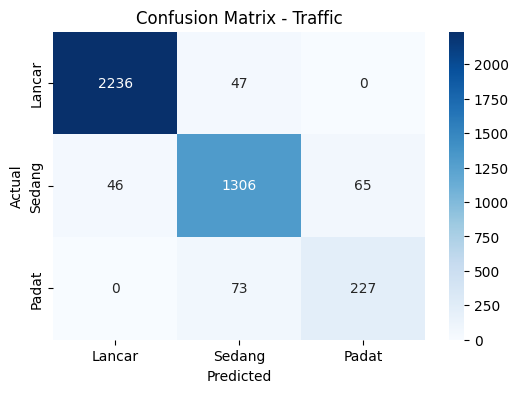


Evaluasi Performa Model
Rasio normal (<= 1.3). Modelnya stabil, baik pada metrik (Kestabilan) MAE, ataupun (Penangkapan outlier) RMSE


In [16]:
mae_t = mean_absolute_error(y_test_t, y_pred_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
r2_t = r2_score(y_test_t, y_pred_t)

# Rasio The "Fatal Error" Rule
rasio_t = rmse_t / mae_t if mae_t > 0 else 0

# Cross Validation CV=5
cv_scores_t = cross_val_score(rf_model, X_train_t_scaled, y_train_t, cv=5, scoring='r2')

print(f"R-squared Score : {r2_t:.4f}")
print(f"CV R2 (5 folds) : {cv_scores_t.mean():.4f} (+/- {cv_scores_t.std() * 2:.4f})")
print(f"MAE             : {mae_t:.4f} kendaraan")
print(f"RMSE            : {rmse_t:.4f} kendaraan")
print(f"Rasio RMSE/MAE  : {rasio_t:.2f}")

print("\n--- KONVERSI KE KLASIFIKASI UNTUK CONFUSION MATRIX ---")
def get_congestion_level(density):
    if density > 80: return "Padat"
    elif density > 40: return "Sedang"
    else: return "Lancar"

y_test_class_t = [get_congestion_level(d) for d in y_test_t]
y_pred_class_t = [get_congestion_level(d) for d in y_pred_t]

acc_t = accuracy_score(y_test_class_t, y_pred_class_t)
print(f"Akurasi Klasifikasi: {acc_t * 100:.2f}%")

cm_t = confusion_matrix(y_test_class_t, y_pred_class_t, labels=["Lancar", "Sedang", "Padat"])
plt.figure(figsize=(6,4))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues', xticklabels=["Lancar", "Sedang", "Padat"], yticklabels=["Lancar", "Sedang", "Padat"])
plt.title("Confusion Matrix - Traffic")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nEvaluasi Performa Model")
if rasio_t <= 1.3:
  print("Rasio normal (<= 1.3). Modelnya stabil, baik pada metrik (Kestabilan) MAE, ataupun (Penangkapan outlier) RMSE")
else:
    print("Rasio tinggi (> 1.3). perlu dilakukan evaluasi lebih lanjut mengenai proses pemodelan, dan disesuaikan dengan tujuan")

# Bagian 2: Model Prediksi Ketersediaan Parkir
**Tujuan Model:** Memprediksi persentase keterisian / kepaadaatn lahan parkir memakai gradient boosting

### 2.1 Load + Preprocessing

In [17]:
# 1. Load Dataset
df_park = pd.read_csv('parking_history.csv')

# 2. Pembersihan & Outlier (Preprocessing)
df_park = df_park.drop_duplicates(subset=['timestamp', 'zone_id'])
df_park['occupancy_rate'] = df_park['occupancy_rate'].interpolate(method='linear')
Q1_p = df_park['occupancy_rate'].quantile(0.25)
Q3_p = df_park['occupancy_rate'].quantile(0.75)
IQR_p = Q3_p - Q1_p
upper_bound_p = min(1.0, Q3_p + 1.5 * IQR_p) # Keterisian tidak mungkin > 1.0 (100%)
df_park['occupancy_rate'] = np.where(df_park['occupancy_rate'] > upper_bound_p, upper_bound_p, df_park['occupancy_rate'])

### EDA Analisis Kepadatan Parkir

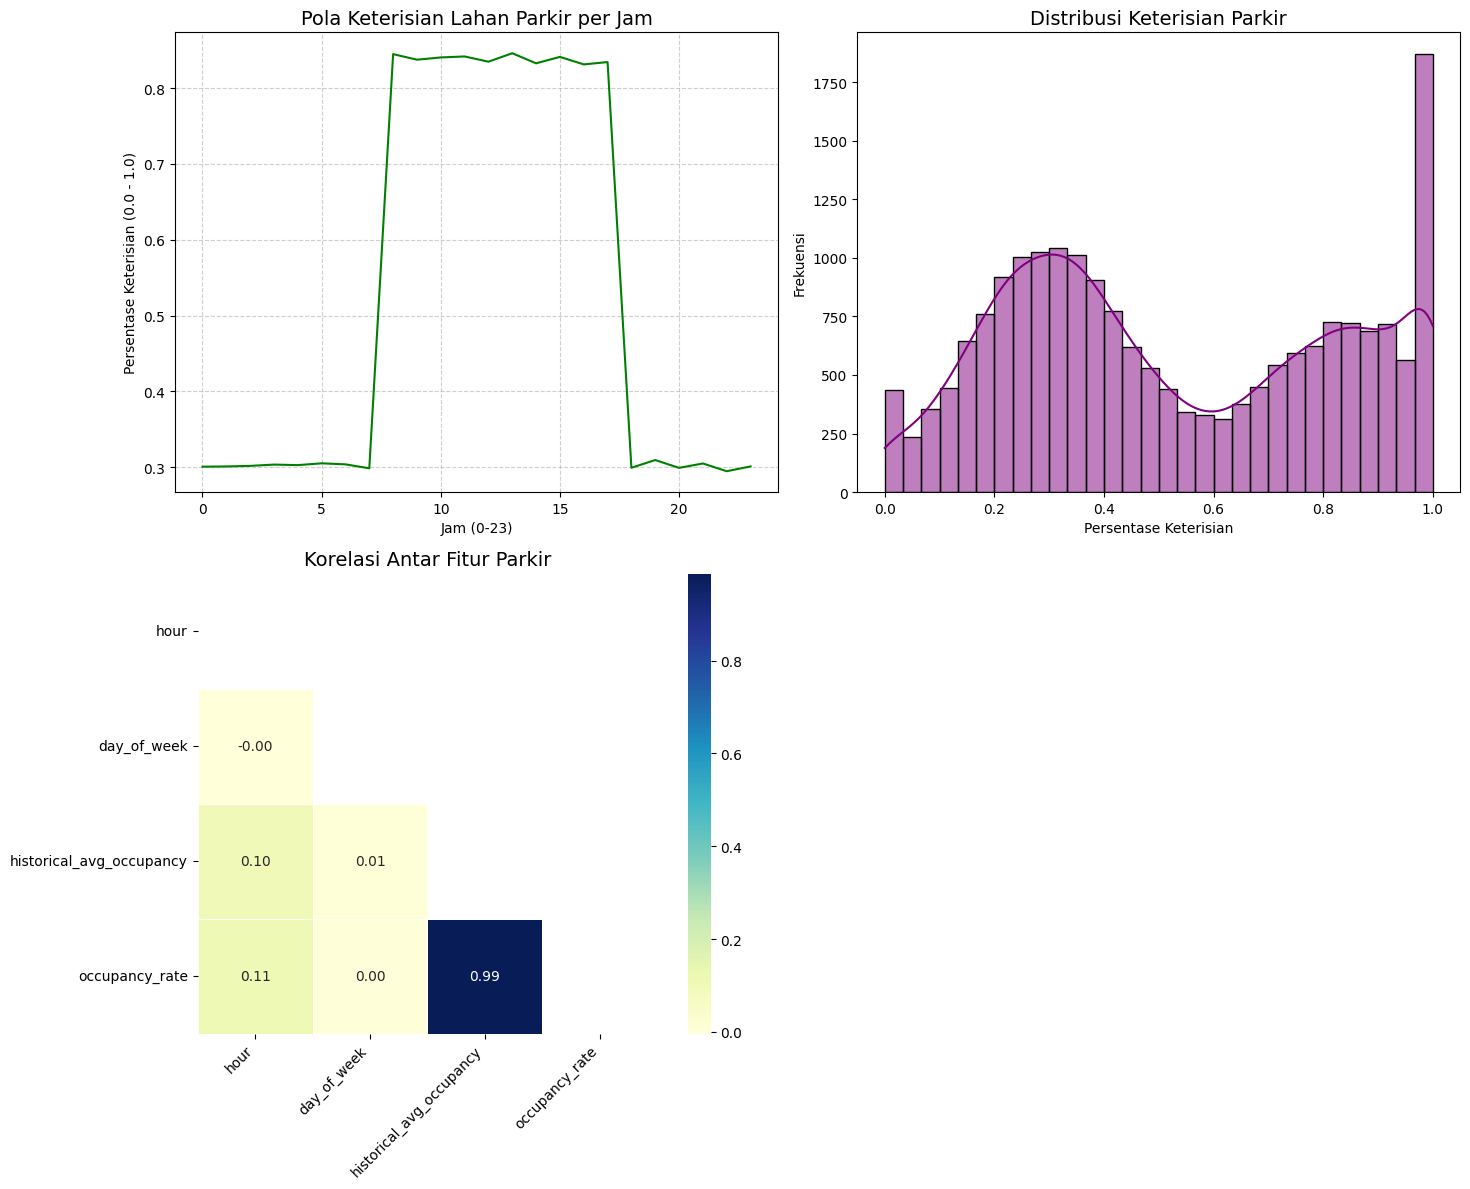

In [5]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.lineplot(data=df_park, x='hour', y='occupancy_rate', errorbar=None, color='green')
plt.title("Pola Keterisian Lahan Parkir per Jam", fontsize=14)
plt.xlabel("Jam (0-23)")
plt.ylabel("Persentase Keterisian (0.0 - 1.0)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 2, 2)
sns.histplot(df_park['occupancy_rate'], kde=True, color='purple', bins=30)
plt.title("Distribusi Keterisian Parkir", fontsize=14)
plt.xlabel("Persentase Keterisian")
plt.ylabel("Frekuensi")

plt.subplot(2, 2, 3)
numeric_cols_p = df_park.select_dtypes(include=['float64', 'int64'])
corr_matrix_p = numeric_cols_p.corr()
mask_p = np.triu(np.ones_like(corr_matrix_p, dtype=bool))

sns.heatmap(
    corr_matrix_p,
    mask=mask_p,
    annot=True,
    cmap='YlGnBu',
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Korelasi Antar Fitur Parkir", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

R-squared Score : 0.9750
CV R2 (5 folds) : 0.9761 (+/- 0.0011)
MAE             : 0.0374 (atau 3.74%)
RMSE            : 0.0474 (atau 4.74%)
Rasio RMSE/MAE  : 1.27

--- KONVERSI KE KLASIFIKASI UNTUK CONFUSION MATRIX ---
Akurasi Klasifikasi: 92.47%


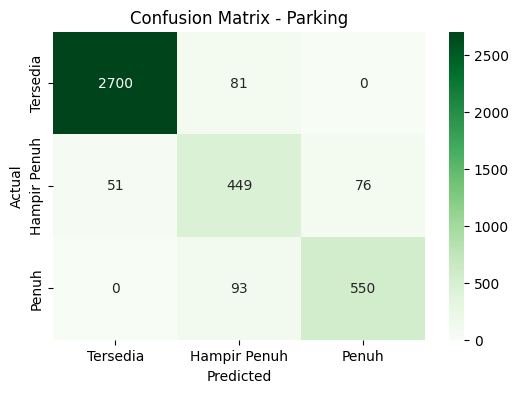

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Modelling
le_zone = LabelEncoder()
df_park['zone_id_enc'] = le_zone.fit_transform(df_park['zone_id'])

X_park = df_park[['hour', 'day_of_week', 'zone_id_enc', 'historical_avg_occupancy']]
y_park = df_park['occupancy_rate']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_park, y_park, test_size=0.2, random_state=42)

scaler_park = StandardScaler()
X_train_p_scaled = scaler_park.fit_transform(X_train_p)
X_test_p_scaled = scaler_park.transform(X_test_p)

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_p_scaled, y_train_p)
y_pred_p = gb_model.predict(X_test_p_scaled)

# 2. Evaluasi & Thresholding
mae_p = mean_absolute_error(y_test_p, y_pred_p)
rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
r2_p = r2_score(y_test_p, y_pred_p)
rasio_p = rmse_p / mae_p if mae_p > 0 else 0

cv_scores_p = cross_val_score(gb_model, X_train_p_scaled, y_train_p, cv=5, scoring='r2')

print(f"R-squared Score : {r2_p:.4f}")
print(f"CV R2 (5 folds) : {cv_scores_p.mean():.4f} (+/- {cv_scores_p.std() * 2:.4f})")
print(f"MAE             : {mae_p:.4f} (atau {mae_p*100:.2f}%)")
print(f"RMSE            : {rmse_p:.4f} (atau {rmse_p*100:.2f}%)")
print(f"Rasio RMSE/MAE  : {rasio_p:.2f}")

print("\n--- KONVERSI KE KLASIFIKASI UNTUK CONFUSION MATRIX ---")
def get_parking_label(occ_rate):
    if occ_rate >= 0.90: return "Penuh"
    elif occ_rate >= 0.75: return "Hampir Penuh"
    else: return "Tersedia"

y_test_class_p = [get_parking_label(o) for o in y_test_p]
y_pred_class_p = [get_parking_label(o) for o in y_pred_p]

acc_p = accuracy_score(y_test_class_p, y_pred_class_p)
print(f"Akurasi Klasifikasi: {acc_p * 100:.2f}%")

cm_p = confusion_matrix(y_test_class_p, y_pred_class_p, labels=["Tersedia", "Hampir Penuh", "Penuh"])
plt.figure(figsize=(6,4))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Greens', xticklabels=["Tersedia", "Hampir Penuh", "Penuh"], yticklabels=["Tersedia", "Hampir Penuh", "Penuh"])
plt.title("Confusion Matrix - Parking")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# Bagian 3: Model Deteksi Anomali
Tahapan ini menggunakan metode unsupervised

In [19]:
from sklearn.ensemble import IsolationForest

# 1. Ekstraksi Fitur dari Dataset Utama (Unsupervised)
# Kita TIDAK butuh dataset berlabel khusus anomali. Kita ekstrak langsung dari traffic_history!
df_traffic['sensor_value'] = df_traffic['vehicle_density']
df_traffic['timestamp_hour'] = df_traffic['hour']
df_traffic['rolling_mean_1h'] = df_traffic.groupby('location')['sensor_value'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
df_traffic['z_score'] = df_traffic.groupby('location')['sensor_value'].transform(lambda x: (x - x.mean()) / x.std())
df_traffic['z_score'] = df_traffic['z_score'].fillna(0)

X_anomaly = df_traffic[['sensor_value', 'timestamp_hour', 'rolling_mean_1h', 'z_score']]

# 2. Training Model
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_traffic['is_anomaly'] = iso_forest.fit_predict(X_anomaly)

# Hasil
# 1 = Normal, -1 = Anomali
jumlah_anomali = len(df_traffic[df_traffic['is_anomaly'] == -1])
print(f"Model berhasil dilatih. Ditemukan {jumlah_anomali} kejadian anomali dari {len(df_traffic)} data sensor.")


Model berhasil dilatih. Ditemukan 1000 kejadian anomali dari 20000 data sensor.
